In [17]:
from sklearn import feature_selection as ftr_sel
import numpy as np
import sklearn.datasets as datasets
import sklearn.model_selection as skms
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [3]:
kwargs = dict(test_size=0.3, random_state=42)
wine = datasets.load_wine()
tts = skms.train_test_split(wine.data, wine.target, **kwargs)
(wine_train, wine_test, wine_train_tgt, wine_test_tgt) = tts

diabetes = datasets.load_diabetes()

tts = skms.train_test_split(diabetes.data, diabetes.target, **kwargs)
(diabetes_train_ftrs, diabetes_test_ftrs, diabetes_train_tgt,  diabetes_test_tgt) = tts

In [7]:
ftrsel = ftr_sel.SelectKBest(ftr_sel.f_classif, k=5)
ftrsel.fit_transform(wine_train, wine_train_tgt)


keepers_idx = ftrsel.get_support()
print(np.array(wine.feature_names)[keepers_idx])

['alcohol' 'flavanoids' 'color_intensity' 'od280/od315_of_diluted_wines'
 'proline']


Nelinearne veze - klasifokacija

In [8]:
ftrsel = ftr_sel.SelectKBest(ftr_sel.mutual_info_classif, k=5)
ftrsel.fit_transform(wine_train, wine_train_tgt)


keepers_idx = ftrsel.get_support()
print(np.array(wine.feature_names)[keepers_idx])

['flavanoids' 'color_intensity' 'hue' 'od280/od315_of_diluted_wines'
 'proline']


Linearna veza - Regresor

In [10]:
frtsel = ftr_sel.SelectPercentile(ftr_sel.f_regression, percentile=25)
frtsel.fit_transform(diabetes_train_ftrs, diabetes_train_tgt)

print(np.array(diabetes.feature_names)[frtsel.get_support()])

['bmi' 'bp' 's5']


Nelinearne veze. Regresija mutual_info_regression()

In [11]:
ftrsel = ftr_sel.SelectPercentile(ftr_sel.mutual_info_regression, percentile=25)
ftrsel.fit_transform(diabetes_train_ftrs, diabetes_train_tgt)

print(np.array(diabetes.feature_names)[ftrsel.get_support()])


['bmi' 's4' 's5']


##SVM - kernal metoda

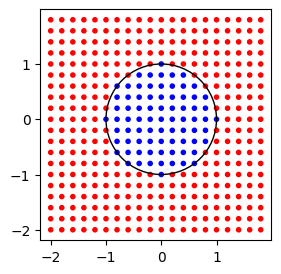

In [16]:
def plot_boundary(ax, data, tgt, model, dims, grid_step = .01):
    # grab a 2D view of the data and get limits
    twoD = data[:, list(dims)]
    min_x1, min_x2 = np.min(twoD, axis=0) + 2 * grid_step
    max_x1, max_x2 = np.max(twoD, axis=0) - grid_step


    # make a grid of points and predict at them
    xs, ys = np.mgrid[min_x1:max_x1:grid_step,
                      min_x2:max_x2:grid_step]
    grid_points = np.c_[xs.ravel(), ys.ravel()]
    # warning:  non-cv fit
    preds = model.fit(twoD, tgt).predict(grid_points).reshape(xs.shape)

    # plot the predictions at the grid points
    ax.pcolormesh(xs,ys,preds,cmap=plt.cm.coolwarm)
    ax.set_xlim(min_x1, max_x1)#-grid_step)
    ax.set_ylim(min_x2, max_x2)#-grid_step)

def get_model_name(model):
    ' return name of model (class) as a string '
    return str(model.__class__).split('.')[-1][:-2]


xs, ys = np.mgrid[-2:2:.2, -2:2:.2]
tgt = (xs**2 + ys**2 > 1).flatten()
data = np.c_[xs.flat, ys.flat]
fig, ax = plt.subplots(figsize=(4,3))
ax.scatter(xs, ys, c=np.where(tgt, 'r', 'b'), marker='.')
ax.set_aspect('equal');
circ = plt.Circle((0,0), 1, color='k', fill=False)
ax.add_patch(circ)

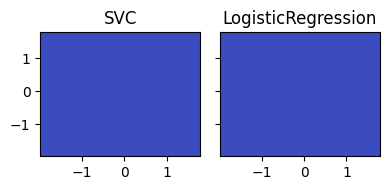

In [19]:
from sklearn import svm, linear_model

shootout_linear = [svm.SVC(kernel='linear'), linear_model.LogisticRegression()]

fig, axes = plt.subplots(1, 2, figsize=(4, 2), sharey=True)
for mod, ax in zip(shootout_linear, axes):
    plot_boundary(ax, data, tgt, mod, [0,1])
    ax.set_title(get_model_name(mod))
plt.tight_layout()
plt.show()

In [20]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score

In [21]:
from os import pipe
X = data
y = np.asarray(tgt)

for model in shootout_linear:
  pipe = Pipeline([ ('scaler', StandardScaler()), ('clf', model) ])

  pipe.fit(X, y)
  y_pred = pipe.predict(X)
  f1_macro = f1_score(y, y_pred, average='macro')
  print(f'{get_model_name(model)}: {f1_macro} = {f1_macro:-4f}')

SVC: 0.4467496542185339 = 0.446750
LogisticRegression: 0.4467496542185339 = 0.446750


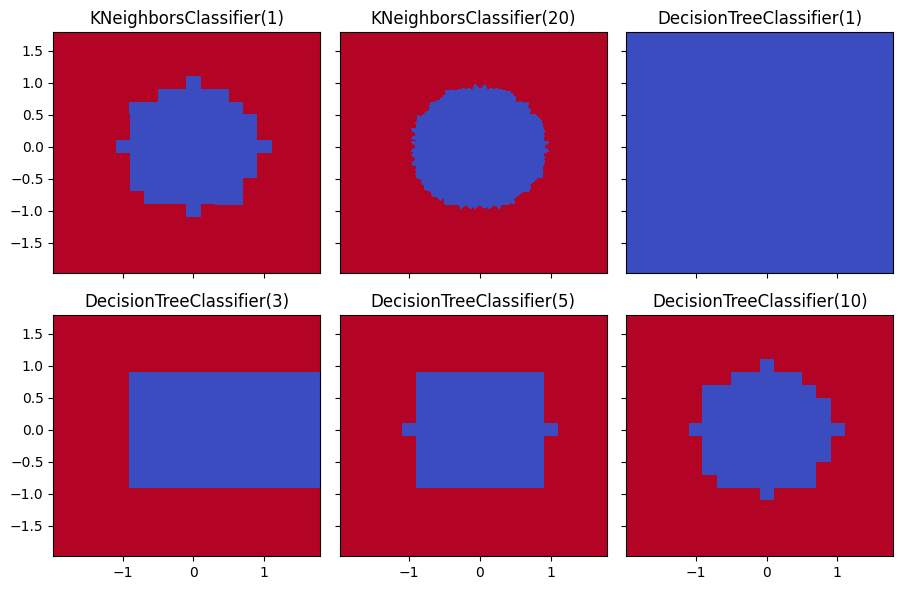

In [24]:
from sklearn import neighbors, tree

knc_p, dtc_p = [1,20], [1,3,5,10]
KNC = neighbors.KNeighborsClassifier
DTC = tree.DecisionTreeClassifier

shootout_nonlin = ([(KNC(n_neighbors=p), p) for p in knc_p] + [(DTC(max_depth=p), p) for p in dtc_p])

fig, axes = plt.subplots(2, 3, figsize=(9, 6),sharex=True, sharey=True)
for (mod, param), ax in zip(shootout_nonlin, axes.flat):
  plot_boundary(ax, data, tgt, mod, [0,1])
  ax.set_title(get_model_name(mod) + "({})".format(param))
plt.tight_layout()
plt.show()

Novi oblik podataka: (400, 4)
Prvi red: [-2. -2.  4.  4.]


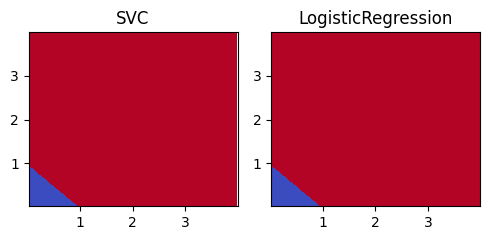

In [25]:
new_data = np.concatenate([data, data**2], axis=1)
print("Novi oblik podataka:", new_data.shape)
print("Prvi red:", new_data[0])


fig, axes = plt.subplots(1, 2, figsize=(5, 2.5))
for mod, ax in zip(shootout_linear, axes):
    plot_boundary(ax, new_data, tgt, mod, [2, 3])
    ax.set_title(get_model_name(mod))
plt.tight_layout()

In [26]:
X = new_data
y = np.asarray(tgt)

for model in shootout_linear:
  pipe = Pipeline([ ('scaler', StandardScaler()), ('clf', model) ])

  pipe.fit(X, y)
  y_pred = pipe.predict(X)
  f1_macro = f1_score(y, y_pred, average='macro')
  print(f'{get_model_name(model)}: {f1_macro} = {f1_macro:-4f}')

SVC: 0.9878776858502287 = 0.987878
LogisticRegression: 0.9835897435897436 = 0.983590


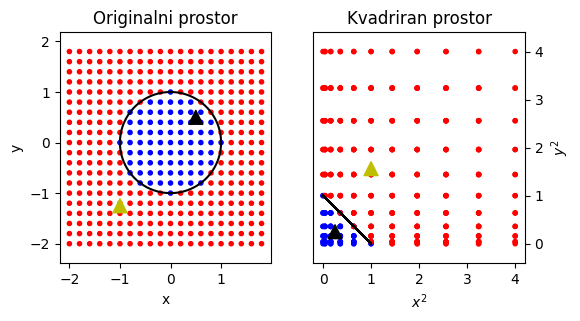

In [27]:
# testne tocke
test_points = np.array([[.5,.5],
                       [-1, -1.25]])

circle_pts = np.linspace(0,2*np.pi,100)
circle_xs, circle_ys = np.sin(circle_pts), np.cos(circle_pts)

fig, axes = plt.subplots(1,2, figsize=(6,3))

labels = [('x',     'y',     'Originalni prostor'),
          ('$x^2$', '$y^2$', 'Kvadriran prostor')]

funcs = [lambda x:x,    # for original ftrs
         lambda x:x**2] # for squared ftrs

for ax, func, lbls in zip(axes, funcs, labels):
    ax.plot(func(circle_xs), func(circle_ys), 'k')
    ax.scatter(*func(data.T), c=np.where(tgt, 'r', 'b'), marker='.')
    ax.scatter(*func(test_points.T), c=['k', 'y'], s=100, marker='^')

    ax.axis('equal')
    ax.set_xlabel(lbls[0])
    ax.set_ylabel(lbls[1])
    ax.set_title(lbls[2])

axes[1].yaxis.tick_right()
axes[1].yaxis.set_label_position("right")

In [28]:
from sklearn import metrics

k_data = metrics.pairwise.polynomial_kernel(data, data, degree=2)
print('first examlpe:', data[0])
print('first examlpe in kernelized fatures:', k_data[0])
print('examlpe in original fatures:', data[0].shape)
print('examlpe in kernelized fatures:', k_data[0].shape)
print('examlpe in both:', len(data), len(k_data))

first examlpe: [-2. -2.]
first examlpe in kernelized fatures: [2.50000000e+01 2.30400000e+01 2.11600000e+01 1.93600000e+01
 1.76400000e+01 1.60000000e+01 1.44400000e+01 1.29600000e+01
 1.15600000e+01 1.02400000e+01 9.00000000e+00 7.84000000e+00
 6.76000000e+00 5.76000000e+00 4.84000000e+00 4.00000000e+00
 3.24000000e+00 2.56000000e+00 1.96000000e+00 1.44000000e+00
 2.30400000e+01 2.11600000e+01 1.93600000e+01 1.76400000e+01
 1.60000000e+01 1.44400000e+01 1.29600000e+01 1.15600000e+01
 1.02400000e+01 9.00000000e+00 7.84000000e+00 6.76000000e+00
 5.76000000e+00 4.84000000e+00 4.00000000e+00 3.24000000e+00
 2.56000000e+00 1.96000000e+00 1.44000000e+00 1.00000000e+00
 2.11600000e+01 1.93600000e+01 1.76400000e+01 1.60000000e+01
 1.44400000e+01 1.29600000e+01 1.15600000e+01 1.02400000e+01
 9.00000000e+00 7.84000000e+00 6.76000000e+00 5.76000000e+00
 4.84000000e+00 4.00000000e+00 3.24000000e+00 2.56000000e+00
 1.96000000e+00 1.44000000e+00 1.00000000e+00 6.40000000e-01
 1.93600000e+01 1.76400

In [29]:
X = k_data
y = np.asarray(tgt)

for model in shootout_linear:
  pipe = Pipeline([ ('scaler', StandardScaler()), ('clf', model) ])

  pipe.fit(X, y)
  y_pred = pipe.predict(X)
  f1_macro = f1_score(y, y_pred, average='macro')
  print(f'{get_model_name(model)}: {f1_macro} = {f1_macro:-4f}')

SVC: 0.9751285027358647 = 0.975129
LogisticRegression: 0.9835897435897436 = 0.983590


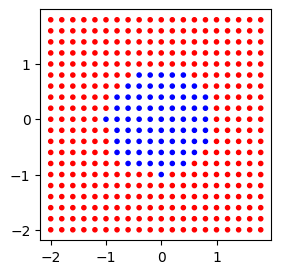

In [30]:
fig, ax = plt.subplots(figsize=(4,3))
# treniramo model sa k_data umjesto originalnih
preds  = (linear_model.LogisticRegression()
                      .fit(k_data, tgt)
                      .predict(k_data))
ax.scatter(xs, ys, c=np.where(preds, 'r', 'b'), marker='.')
ax.set_aspect('equal')

In [31]:
from sklearn import svm
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score


X, y = load_digits(return_X_y=True)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


sv_classifiers = {
    "LinearSVC"    : svm.LinearSVC(),
    "SVC(linear)"  : svm.SVC(kernel='linear'),
    "SVC(poly=1)"  : svm.SVC(kernel='poly', degree=1),
    "SVC(poly=2)"  : svm.SVC(kernel='poly', degree=2),
    "SVC(poly=3)"  : svm.SVC(kernel='poly', degree=3),
    "SVC(rbf,.5)"  : svm.SVC(kernel='rbf', gamma=0.5),
    "SVC(rbf,1.0)" : svm.SVC(kernel='rbf', gamma=1.0),
    "SVC(rbf,2.0)" : svm.SVC(kernel='rbf', gamma=2.0)}


for name, clf in sv_classifiers.items():
    pipe = Pipeline([("scaler", StandardScaler()), ("clf", clf)])
    pipe.fit(X_tr, y_tr)
    acc = accuracy_score(y_te, pipe.predict(X_te))
    print(f"{name:12s} | accuracy = {acc:.4f}")

LinearSVC    | accuracy = 0.9556
SVC(linear)  | accuracy = 0.9750
SVC(poly=1)  | accuracy = 0.9861
SVC(poly=2)  | accuracy = 0.9778
SVC(poly=3)  | accuracy = 0.9722
SVC(rbf,.5)  | accuracy = 0.3861
SVC(rbf,1.0) | accuracy = 0.1361
SVC(rbf,2.0) | accuracy = 0.1167


In [39]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score


X, y = load_digits(return_X_y=True)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

pipe = Pipeline([("scaler", StandardScaler()), ("clf", SVC(kernel="rbf"))])

param_grid = {"clf__C": [0.1, 1, 10, 100], "clf__gamma": ["scale", "auto", 0.01, 0.1, 1, 10]}


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(pipe, param_grid, cv=cv, scoring="accuracy", n_jobs=-1)
grid.fit(X_tr, y_tr)
y_pred = grid.best_estimator_.predict(X_te)
print(f"{accuracy_score(y_te, y_pred):.4f}")
print(grid.best_params_)
print(grid.best_score_)



0.9750
{'clf__C': 1, 'clf__gamma': 'auto'}
0.9819081494386372


#PCA metoda